In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Пояснение к Данным
    1.**Cylinders** — количество цилиндров в двигателе (обычно 4, 6 или 8). Больше цилиндров — мощнее мотор, но и бензина он «ест» значительно больше.
    2.**Displacement** — рабочий объем двигателя. Показывает суммарный объем всех цилиндров. Чем больше объем, тем тяжелее мотору быть экономичным.
    3.**Horsepower** — мощность в лошадиных силах. Напрямую связана с расходом: высокая мощность требует большего количества топливно-воздушной смеси.
    4.**Weight** — вес автомобиля (в фунтах). Главный враг экономичности. Тяжелой машине нужно колоссальное количество энергии, чтобы сдвинуться с места и преодолевать силы инерции.
    5.**Acceleration** — ускорение (время разгона от 0 до 60 миль в час в секундах). Здесь связь обратная: чем больше секунд нужно машине на разгон, тем она медленнее и, как правило, экономичнее.
    6.**Model year** — год выпуска автомобиля (в датасете были 1970–1982 года). Отражает инженерный прогресс: со временем двигатели становились эффективнее, и при том же весе машины более свежих годов выпуска имели более высокий mpg.
    7.**Origin** — регион производства (1 — США, 2 — Европа, 3 — Азия). Помогает модели учесть особенности автопрома: например, японские машины традиционно делались маленькими и экономичными, а американские — огромными и прожорливыми.
    8.**MPG** - насколько автомобиль экономичен чем больше тем лучше. Сколько миль (1.6 км) пройедет автомобильза 1 галон (3.785 л)?

## ВСЯ РАБОТА

In [2]:
df = pd.read_csv('../DATA/auto-mpg.csv')

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [7]:
df['model year'] = df['model year'] + 1900

In [8]:
def take_name(name):
    names = name.split()
    return names[0]

In [9]:
df['car name'] = df['car name'].apply(take_name)

In [10]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,1970,1,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,1970,1,buick
2,18.0,8,318.0,150.0,3436,11.0,1970,1,plymouth
3,16.0,8,304.0,150.0,3433,12.0,1970,1,amc
4,17.0,8,302.0,140.0,3449,10.5,1970,1,ford


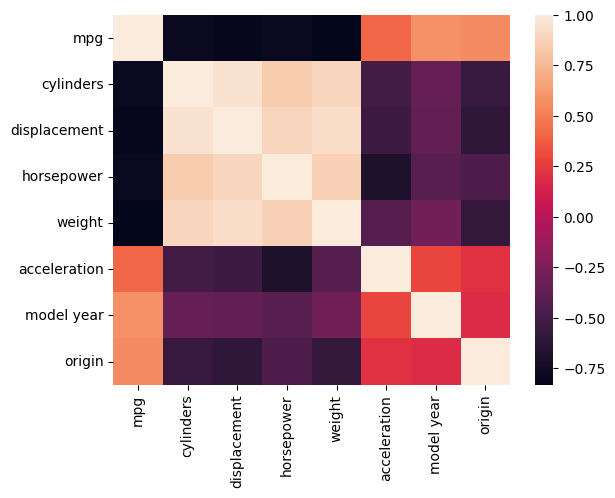

In [11]:
sns.heatmap(df.corr(numeric_only=True));

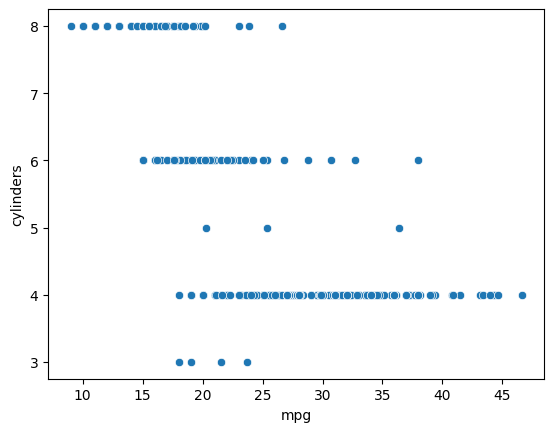

In [12]:
sns.scatterplot(x='mpg', y='cylinders', data=df);

In [13]:
df[(df['cylinders'] == 5)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
274,20.3,5,131.0,103.0,2830,15.9,1978,2,audi
297,25.4,5,183.0,77.0,3530,20.1,1979,2,mercedes
327,36.4,5,121.0,67.0,2950,19.9,1980,2,audi


In [14]:
df = df.drop(274)
df = df.drop(297)
df = df.drop(327)

In [15]:
df[(df['cylinders'] == 3)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
71,19.0,3,70.0,97.0,2330,13.5,1972,3,mazda
111,18.0,3,70.0,90.0,2124,13.5,1973,3,maxda
243,21.5,3,80.0,110.0,2720,13.5,1977,3,mazda
334,23.7,3,70.0,100.0,2420,12.5,1980,3,mazda


In [16]:
df = df.drop(71)
df = df.drop(111)
df = df.drop(243)
df = df.drop(334)

In [17]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,1970,1,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,1970,1,buick
2,18.0,8,318.0,150.0,3436,11.0,1970,1,plymouth
3,16.0,8,304.0,150.0,3433,12.0,1970,1,amc
4,17.0,8,302.0,140.0,3449,10.5,1970,1,ford


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           391 non-null    float64
 1   cylinders     391 non-null    int64  
 2   displacement  391 non-null    float64
 3   horsepower    385 non-null    float64
 4   weight        391 non-null    int64  
 5   acceleration  391 non-null    float64
 6   model year    391 non-null    int64  
 7   origin        391 non-null    int64  
 8   car name      391 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.5+ KB


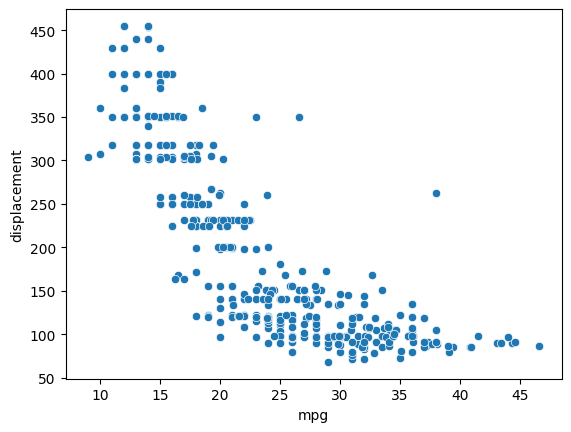

In [19]:
sns.scatterplot(x='mpg', y='displacement', data=df);

In [20]:
df[(df['displacement'] >= 250) & (df['mpg'] > 35)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
387,38.0,6,262.0,85.0,3015,17.0,1982,1,oldsmobile


In [21]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,1970,1,chevrolet
1,15.0,8,350.0,165.0,3693,11.5,1970,1,buick
2,18.0,8,318.0,150.0,3436,11.0,1970,1,plymouth
3,16.0,8,304.0,150.0,3433,12.0,1970,1,amc
4,17.0,8,302.0,140.0,3449,10.5,1970,1,ford


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           391 non-null    float64
 1   cylinders     391 non-null    int64  
 2   displacement  391 non-null    float64
 3   horsepower    385 non-null    float64
 4   weight        391 non-null    int64  
 5   acceleration  391 non-null    float64
 6   model year    391 non-null    int64  
 7   origin        391 non-null    int64  
 8   car name      391 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.5+ KB


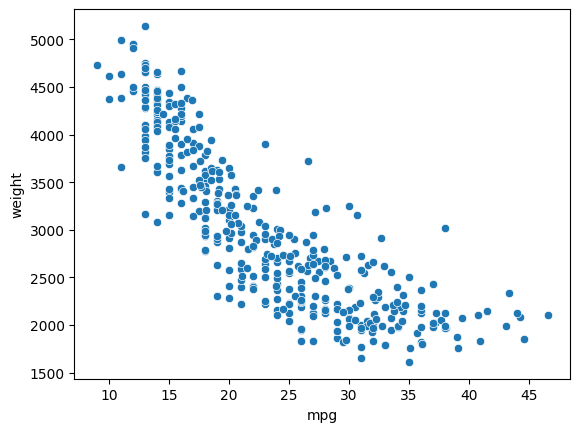

In [23]:
sns.scatterplot(x='mpg', y='weight', data=df);

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import KNNImputer

In [25]:
X = df.drop('mpg', axis=1)

In [26]:
y = df['mpg']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=104)

In [28]:
cat_features = X_train.select_dtypes(include='object').columns.tolist()

In [29]:
num_features = X_train.select_dtypes(exclude='object').columns.tolist()

In [30]:
num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', num_transformer, num_features)
    ],
    remainder='passthrough'
)

In [32]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNetCV(cv=10, l1_ratio=[.1, .5, .7, .9, .95, .99, 1]))
])

In [33]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [34]:
pipe.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                    ['car name']),
                                   ('num',
                                    Pipeline(steps=[('imputer', KNNImputer()),
                                                    ('scaler', StandardScaler()),
                                                    ('poly',
                                                     PolynomialFeatures(include_bias=False))]),
                                    ['cylinders', 'displacement', 'horsepower',
                                     'weight', 'acceleration', 'model year',
                                     'origin'])])),
  ('model',
   ElasticNetCV(cv=10, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]))],
 'transform_input': None,
 'verbose': False,
 'preprocessor': ColumnTransformer(remainder='passthrough',
                

In [35]:
y_pred = pipe.predict(X_test)
y_train_pred = pipe.predict(X_train)

In [36]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)

In [37]:
MAE

1.9594363286054624

In [38]:
MSE

8.69497075074481

In [39]:
RMSE

np.float64(2.948723579914674)

In [40]:
r2_test

0.8660248975615554

In [41]:
r2_train

0.9136568215765615

In [42]:
df['mpg'].mean()

np.float64(23.515345268542198)

In [43]:
best_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_model.l1_ratio_}")

Лучшее значение alpha: 0.02279439600790179
Лучшее значение l1_ratio: 0.5


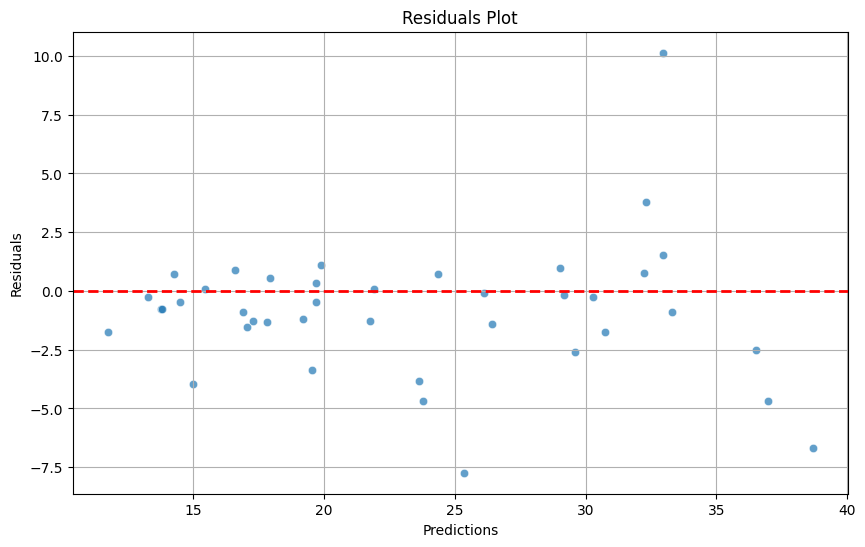

In [44]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)

plt.title('Residuals Plot')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.grid(True)

In [45]:
pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [46]:
y_full_pred = pipe.predict(X)

In [60]:
best_final_model = pipe.named_steps['model']
print(f"Лучшее значение alpha: {best_final_model.alpha_}")
print(f"Лучшее значение l1_ratio: {best_final_model.l1_ratio_}")

Лучшее значение alpha: 0.024732340877710143
Лучшее значение l1_ratio: 0.5


In [61]:
r2_full = r2_score(y, y_full_pred)

In [62]:
r2_full

0.9091807709462704

In [63]:
df['car name'].unique()

array(['chevrolet', 'buick', 'plymouth', 'amc', 'ford', 'pontiac',
       'dodge', 'toyota', 'datsun', 'volkswagen', 'peugeot', 'audi',
       'saab', 'bmw', 'chevy', 'hi', 'mercury', 'opel', 'fiat',
       'oldsmobile', 'chrysler', 'volvo', 'renault', 'toyouta', 'honda',
       'subaru', 'chevroelt', 'capri', 'vw', 'mercedes-benz', 'cadillac',
       'mazda', 'maxda', 'vokswagen', 'triumph', 'nissan'], dtype=object)

In [64]:
my_car_data = {
    'cylinders': [4, 4],
    'displacement': [120.0, 80],
    'horsepower': [90, 55],
    'weight': [3500, 1100],
    'acceleration': [16.5, 21.0],
    'model year': [1982, 1982],
    'origin': [1, 3],
    'car name': ['mazda', 'honda']
}

In [65]:
my_car_df = pd.DataFrame(my_car_data)

In [66]:
predicted_mpg = pipe.predict(my_car_df)

In [67]:
predicted_mpg

array([24.5792539 , 47.74950517])

In [75]:
import json
import os

advanced_report = {
    "project": "MPG Prediction",
    "model": "ElasticNetCV",
    "trained_date": '2026-07',
    "test_parameters": {
        "alpha": best_model.alpha_,
        "l1_ratio": best_model.l1_ratio_,
        "cv": best_model.cv
    },
    "final_parameters": {
        "alpha": best_final_model.alpha_,
        "l1_ratio":  best_final_model.l1_ratio_,
        "cv": best_final_model.cv
    },
    "metrics": {
        "RMSE": RMSE,
        "MAE": MAE,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "R2_full": r2_full,
        "Mean_MPG": df['mpg'].mean()
    }
}


filename = "model_description.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(advanced_report, f, indent=4, ensure_ascii=False)

In [69]:
from joblib import dump, load

In [70]:
dump(pipe, "model/mpg_model_predict_elastic_net_cv_2026_v1.pkl")

['model/mpg_model_predict_elastic_net_cv_2026_v1.pkl']

In [71]:
loaded_pipe = load('model/mpg_model_predict_elastic_net_cv_2026_v1.pkl')

In [72]:
loaded_pipe.predict(my_car_df)

array([24.5792539 , 47.74950517])